# 13B. Log-Mel CNN의 Validation 튜닝

기존 10초 Log-Mel 캐시를 사용해 CNN Baseline과 두 단계의 후보를 비교했다. Learning rate·dropout을 먼저, batch size·weight decay를 다음에 비교하고 Validation Track EER로 checkpoint와 설정을 골랐다. 이 노트북에서는 Test를 평가하지 않았다.

## 1. 입력과 평가 기준

기존 Log-Mel 캐시는 24 kHz, FFT 1,024, hop 240, Mel 128개로 만든 `[1,128,1001]` 입력이다. 첫 축은 채널, 마지막 축은 시간이다. 캐시나 10초 경계를 다시 만들지 않는다.

REAL=0, FAKE=1이며 CNN 점수는 `sigmoid(logit)`이다. 가중 BCE로 학습했으므로 보정된 실제 확률로 보지 않는다. 곡 점수는 같은 곡의 Segment 점수 평균이다. 모델·epoch·Segment/Track 임계값은 Validation에서만 정하고, Test는 여기서 평가하지 않는다.

EER은 ROC 교점을 보간해 계산한다. 분류 임계값은 유한 ROC 후보 중 |FPR−FNR|가 가장 작은 값으로 정한다. FAKE가 다수이므로 REAL AP와 REAL 오탐도 함께 본다.

In [1]:
# 실행 환경과 난수 시드를 기록하고, Test를 열지 않은 상태에서 출력 경로를 준비한다.
from pathlib import Path
import hashlib, json, random, shutil, time, warnings
from datetime import datetime, timezone
from importlib.metadata import version, PackageNotFoundError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from src.cnn_modeling import LogMelCNN, LogMelDataset, predict_scores
from src.modeling_evaluation import (
    assert_group_disjoint,
    evaluate_binary_predictions,
    select_best_candidate,
)

ROOT = Path.cwd()
MANIFEST = ROOT / "data/metadata/segment_manifest_10s.csv"
CACHE = ROOT / "data/processed/logmel/logmel_10s_float16.npy"
DONE = ROOT / "data/processed/logmel/logmel_10s_done.npy"
INDEX = ROOT / "data/processed/logmel/logmel_10s_index.csv"
OUT = ROOT / "results/model_tuning"
TRIAL_OUT = OUT / "cnn_trial_scores"
TRIAL_CKPT = ROOT / "checkpoints/optimized/cnn_trials"
FINAL_CKPT = ROOT / "checkpoints/optimized"
for path in (OUT, TRIAL_OUT, TRIAL_CKPT, FINAL_CKPT):
    path.mkdir(parents=True, exist_ok=True)
RUN_ID = "cnn_revised_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
SEED = 42
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
        else "cpu"
    )
)
MEL_SETTINGS = dict(
    sr=24000,
    segment_sec=10,
    n_fft=1024,
    hop_length=240,
    n_mels=128,
    fmax=12000,
    center=True,
    power=2.0,
    top_db=80,
    ref="max",
    fixed_scale="(dB+40)/40",
)


def sha256_file(path):
    """Hash the exact split manifest or cache index used by this run."""
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "unavailable"


VERSIONS = {
    name: package_version(name)
    for name in ("numpy", "pandas", "torch", "scikit-learn", "librosa")
}
print("run_id:", RUN_ID, "| device:", DEVICE, "| package versions:", VERSIONS)


=== RUN NOTEBOOK CELL 2 (code #1) ===
run_id: cnn_revised_20260919T110440Z | device: mps | package versions: {'numpy': '2.3.5', 'pandas': '2.3.3', 'torch': '2.14.0', 'scikit-learn': '1.7.2', 'librosa': '1.0.0'}


실행 ID는 `cnn_revised_20260919T110440Z`이며 장비는 **MPS**로 확인됐다. 출력된 패키지 버전은 NumPy `2.3.5`, pandas `2.3.3`, PyTorch `2.14.0`, scikit-learn `1.7.2`, librosa `1.0.0`이다.

이번 실행의 ID·장비·주요 패키지 버전을 기록해 뒤의 학습 결과와 checkpoint가 어느 환경에서 만들어졌는지 추적할 수 있다.

동일한 seed `42`와 패키지 버전을 사용해도 장비와 연산 구현에 따라 완전히 같은 수치가 보장되지는 않는다. 이 출력은 모델 성능을 의미하지 않는다.

## 2. Manifest와 cache의 동일성 검증

`segment_id` 중복, track 안의 label 불일치, original_audio의 split 중복, cache의 누락 또는 순서 어긋남은 학습을 중단한다. class 수는 이 모델이 실제 loss에 넣는 **Train segment**로 계산하며, split마다 original_audio·track·segment 단위로 보고한다. FAKE가 많은 원본 데이터를 삭제해 1:1로 만들지 않고 전체 데이터를 이용한다. 가중 학습은 track 길이별 기여도 차이까지 없애지는 못한다.

In [2]:
# Manifest와 Log-Mel cache의 ID·순서·shape를 대조해 입력 누수를 막는다.
segments = pd.read_csv(MANIFEST)
cache_index = pd.read_csv(INDEX)
required = {
    "segment_id",
    "track_sample_id",
    "original_audio",
    "label",
    "label_id",
    "split",
}
if not required.issubset(segments.columns):
    raise ValueError(f"Missing manifest columns: {required - set(segments.columns)}")
if (
    segments["segment_id"].duplicated().any()
    or cache_index["segment_id"].duplicated().any()
):
    raise ValueError("Duplicate segment_id")
if not set(segments["label_id"].unique()) == {0, 1}:
    raise ValueError("Expected REAL=0 and FAKE=1")
if ((segments["label"] == "REAL") != (segments["label_id"] == 0)).any():
    raise ValueError("REAL/FAKE label mapping mismatch")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
if set(segments["split"]) != {"train", "val", "test"}:
    raise ValueError("Unexpected split names")
if (segments.groupby("track_sample_id")["label_id"].nunique() > 1).any():
    raise ValueError("Mixed labels within track")
assert_group_disjoint(segments.rename(columns={"original_audio": "original_audio_id"}))
if (
    not segments["segment_id"]
    .reset_index(drop=True)
    .equals(cache_index["segment_id"].reset_index(drop=True))
):
    raise ValueError("Cache index order differs from manifest")
if not np.array_equal(cache_index["logmel_index"].to_numpy(), np.arange(len(segments))):
    raise ValueError("Cache indices are not consecutive manifest row positions")
if not np.load(DONE).all():
    raise ValueError("Log-Mel cache has incomplete rows")
cache = np.load(CACHE, mmap_mode="r")
if cache.shape != (len(segments), 128, 1001):
    raise ValueError(f"Unexpected existing Log-Mel cache shape: {cache.shape}")
# 실제 저장된 sample 텐서와 기존 STFT 설정에서 계산한 frame 수를 함께 확인한다.
expected_frames = 1 + (24000 * 10) // 240
if cache[0].shape != (128, expected_frames):
    raise ValueError("Cache tensor disagrees with existing STFT configuration")
MANIFEST_HASH = sha256_file(MANIFEST)
INDEX_HASH = sha256_file(INDEX)
class_counts = (
    segments.groupby(["split", "label"], sort=False)
    .agg(
        original_audio=("original_audio", "nunique"),
        tracks=("track_sample_id", "nunique"),
        segments=("segment_id", "nunique"),
    )
    .reset_index()
)
display(class_counts)
print("cache tensor:", cache[0].shape, "| manifest SHA256:", MANIFEST_HASH)
train_meta = segments.loc[segments.split == "train"].copy()
val_meta = segments.loc[segments.split == "val"].copy()
# Test metadata와 cache는 무결성 확인만 했다. Test sample을 DataLoader나 평가 함수에 전달하지 않는다.
train_real = int((train_meta.label_id == 0).sum())
train_fake = int((train_meta.label_id == 1).sum())
if train_real == 0 or train_fake == 0:
    raise ValueError("Both classes required in Train")
POS_WEIGHT = train_real / train_fake
print("Train REAL/FAKE segments:", train_real, train_fake, "| pos_weight:", POS_WEIGHT)


=== RUN NOTEBOOK CELL 4 (code #2) ===
   split label  original_audio  tracks  segments
0  train  REAL             207     207       621
1    val  REAL              44      44       132
2   test  REAL              45      45       135
3  train  FAKE             207    2185      6346
4   test  FAKE              45     494      1437
5    val  FAKE              44     483      1406
cache tensor: (128, 1001) | manifest SHA256: 9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3
Train REAL/FAKE segments: 621 6346 | pos_weight: 0.09785691774346045


Train은 REAL 621, FAKE 6,346 segment이고 Validation은 REAL 132, FAKE 1,406 segment다. 기존 cache tensor는 실제로 `(128, 1001)`이며, Train 기준 `pos_weight=0.0978569`다. 원본 manifest SHA256은 `9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3`로 확인되었다.

FAKE가 segment 기준 다수이므로 FAKE=1의 loss 가중치가 1보다 작다. 10초 입력과 기존 STFT/hop 설정으로 1001 frame이 만들어진 cache를 그대로 사용한다.

class weighting은 각 track 길이의 학습 기여도 차이를 지우지 않는다. Test의 class 수는 manifest 무결성 확인으로만 읽었고 Test score/metric은 계산하지 않았다.

## 3. Dataset, DataLoader, CNN 구조

`LogMelDataset.__getitem__`은 기존 cache의 한 row를 float32 `[1,128,T]` tensor, label, segment_id로 반환한다. DataLoader는 mini-batch를 묶으며 Train에서만 shuffle한다. `num_workers=0`은 Mac/Jupyter 환경의 안전한 기본값이며 generator seed=42를 기록한다. Dropout만 탐색 변수로 노출하고 기존 4개 ConvBlock (16→32→64→128), BatchNorm, ReLU, MaxPool, AdaptiveAvgPool, Linear를 유지한다. `forward()`의 shape 변화는 `src/cnn_modeling.py`에 주석으로 기록했다.

In [3]:
# 독립 trial의 난수 초기화와 기존 CNN 구조의 첫 batch shape를 확인한다.
def seed_everything(seed=SEED):
    """Reset Python, NumPy, PyTorch and CUDA state for independent trials."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loaders(batch_size):
    """Build Train shuffle and deterministic Validation DataLoaders from fixed IDs."""
    train_ds = LogMelDataset(train_meta, CACHE, cache_index)
    val_ds = LogMelDataset(val_meta, CACHE, cache_index)
    # Train DataLoader는 모든 segment를 한 번씩 섞고, 고정 generator seed로 순서를 재현한다.
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(SEED),
    )
    # Validation DataLoader는 순서를 섞지 않고 gradient 없이 추론에만 사용한다.
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False
    )
    return train_loader, val_loader


seed_everything()
preview_loader, _ = make_loaders(32)
preview_x, preview_y, preview_ids = next(iter(preview_loader))
if tuple(preview_x.shape[1:]) != (1, 128, 1001):
    raise ValueError(f"Unexpected CNN input: {preview_x.shape}")
print(
    "Batch tensor:",
    tuple(preview_x.shape),
    "| labels:",
    tuple(preview_y.shape),
    "| first ID:",
    preview_ids[0],
)
print("Model parameters:", sum(p.numel() for p in LogMelCNN().parameters()))


=== RUN NOTEBOOK CELL 7 (code #3) ===
Batch tensor: (32, 1, 128, 1001) | labels: (32,) | first ID: seg_006972
Model parameters: 294321


실제 첫 batch는 `(32, 1, 128, 1001)`, label tensor는 `(32,)`였다. 기존 CNN 구조의 parameter 수는 294,321개다.

입력 채널과 Mel/time 축이 모델 정의와 일치해 CNN 학습을 시작할 수 있다.

batch size가 바뀌면 epoch당 optimizer update 수가 달라져 계산 예산도 달라진다. 이 단계는 forward/loss 학습 성능을 검증한 결과가 아니다.

## 4. Baseline과 후보

Baseline은 AdamW, learning rate `1e-3`, dropout `0.3`, weight decay `1e-4`, batch `32`, 최대 20 epoch, patience `4`다. Stage 1은 batch와 weight decay를 고정하고 learning rate×dropout 9개를 비교한다. Stage 2는 선택된 두 값을 고정하고 batch×weight decay를 비교한다. 중복 조합은 재사용한다.

각 trial은 독립 초기화한다. Train에서는 forward→BCE loss→backward→AdamW step으로 가중치를 갱신한다. Validation에서는 가중치를 바꾸지 않고 Track EER, 동률 시 AUC로 checkpoint를 고른다. 4 epoch 연속 개선이 없으면 멈춘다. Baseline과 탐색 후보는 epoch 예산이 달라 별도 trial이다.

In [4]:
# 탐색 전에 Baseline과 후보 격자를 파일로 고정해 사후 선택을 방지한다.
BASELINE = dict(
    lr=1e-3,
    dropout=0.3,
    weight_decay=1e-4,
    batch_size=32,
    max_epochs=20,
    patience=4,
    optimizer="AdamW",
    architecture="historical_4_conv_blocks",
)
SEARCH = dict(
    lr=[1e-4, 3e-4, 1e-3],
    dropout=[0.2, 0.3, 0.5],
    weight_decay=[0, 1e-4, 1e-3],
    batch_size=[16, 32, 64],
    max_epochs=30,
    patience=4,
)
metadata = dict(
    run_id=RUN_ID,
    manifest_sha256=MANIFEST_HASH,
    cache_index_sha256=INDEX_HASH,
    mel_settings=MEL_SETTINGS,
    versions=VERSIONS,
    device=str(DEVICE),
    seed=SEED,
)
(OUT / "cnn_baseline_config.json").write_text(
    json.dumps({**metadata, "baseline": BASELINE}, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print("Saved baseline before training:", OUT / "cnn_baseline_config.json")


=== RUN NOTEBOOK CELL 10 (code #4) ===
Saved baseline before training: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/model_tuning/cnn_baseline_config.json


Baseline 학습 전에 `results/model_tuning/cnn_baseline_config.json`이 저장됐다. 저장된 설정은 기존 4개 ConvBlock 구조, AdamW, LR `1e-3`, dropout `0.3`, weight decay `1e-4`, batch size `32`, max epoch `20`, patience `4`이며, 파일의 실행 ID는 `cnn_revised_20260919T110440Z`다.

Baseline 설정을 학습 전에 기록했으므로 이후 Validation 튜닝 후보와 어떤 조건을 비교했는지 확인할 수 있다.

이 설정은 기존 노트북의 기본 실험값이지 전체 탐색 범위에서 검증된 최적값이 아니다. 설정 저장 자체는 학습 성공이나 Test 성능을 뜻하지 않는다. Test 정보는 설정 결정에 사용하지 않았다.

## 5. 학습, Validation 평가, checkpoint 함수

`train_one_epoch()`은 batch loss를 sample 수로 가중 평균한다. `evaluate_model()`은 추론 score를 공통 평가 함수에 전달하여 Segment/Track 지표와 각각의 Validation threshold를 얻는다. `save_best_checkpoint()`는 개선된 epoch의 모델과 입력 설정·manifest hash를 저장한다. `train_trial()`은 매 trial을 seed=42에서 독립 초기화하고 마지막 epoch 대신 best checkpoint를 복원한다. OOM trial은 상태와 소요시간을 기록하며 다른 오류는 조용히 제외하지 않고 중단한다. 모든 성공 trial은 정확히 같은 Train/Validation segment_id 집합을 사용한다.

In [5]:
# 각 batch를 forward → 가중 BCE → backward → AdamW 순서로 학습하고 Validation으로 epoch를 선택한다.
def train_one_epoch(model, loader, criterion, optimizer):
    """Train one epoch and return sample-weighted loss and update count."""
    model.train()
    total_loss = 0.0
    seen = 0
    updates = 0
    for xb, yb, _ in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        # 1. 이전 batch의 gradient를 초기화한다.
        optimizer.zero_grad(set_to_none=True)
        # 2. Forward: Log-Mel에서 FAKE logit을 계산한다.
        logits = model(xb)
        # 3. Loss: Train segment 비율에서 얻은 weighted BCE를 계산한다.
        loss = criterion(logits, yb)
        # 4. Backward: CNN parameter별 gradient를 계산한다.
        loss.backward()
        # 5. Optimizer step: AdamW로 parameter를 갱신한다.
        # optimizer.step은 계산한 기울기로 실제 가중치를 갱신한다.
        optimizer.step()
        batch_n = len(xb)
        total_loss += float(loss.item()) * batch_n
        seen += batch_n
        updates += 1
    if seen != len(train_meta):
        raise ValueError("A Train segment was dropped")
    return total_loss / seen, updates


def evaluate_model(model, loader, metadata):
    """Score every fixed Validation segment and use shared Segment/Track evaluation."""
    model.eval()
    # Validation에서는 gradient가 필요 없으므로 비활성화한다.
    with torch.no_grad():
        inference_start = time.perf_counter()
        frame = predict_scores(model, loader, metadata, DEVICE)
        frame.attrs["inference_sec"] = time.perf_counter() - inference_start
    if set(frame.segment_id) != set(metadata.segment_id):
        raise ValueError("Validation segment set changed")
    return frame, evaluate_binary_predictions(frame)


def save_best_checkpoint(path, model, config, epoch, report):
    """Save a Validation-selected epoch with enough metadata for final Test inference."""
    # 선택된 epoch의 가중치를 저장해 나중에 같은 모델을 복원한다.
    torch.save(
        dict(
            model_state_dict=model.state_dict(),
            config=config,
            epoch=epoch,
            val_track_eer=report["track"]["eer"],
            val_track_roc_auc=report["track"]["roc_auc"],
            **metadata,
        ),
        path,
    )


def train_trial(trial_id, stage, config, candidate_order):
    """Independently train one candidate and restore its best Validation checkpoint."""
    seed_everything()
    train_loader, val_loader = make_loaders(config["batch_size"])
    model = LogMelCNN(dropout=config["dropout"]).to(DEVICE)
    # 클래스 불균형을 반영한 이진 분류 손실을 준비한다.
    criterion = nn.BCEWithLogitsLoss(
        # 양성(FAKE) 손실 가중치는 해당 Train의 REAL/FAKE 수로 정한다.
        pos_weight=torch.tensor(POS_WEIGHT, dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
    )
    checkpoint_path = TRIAL_CKPT / f"{trial_id}.pt"
    best_key = None
    best_epoch = None
    stale = 0
    history = []
    total_updates = 0
    start = time.perf_counter()
    for epoch in range(1, config["max_epochs"] + 1):
        epoch_start = time.perf_counter()
        train_loss, updates = train_one_epoch(model, train_loader, criterion, optimizer)
        total_updates += updates
        val_scores, report = evaluate_model(model, val_loader, val_meta)
        track = report["track"]
        seg = report["segment"]
        if not np.isfinite(track["eer"]) or not np.isfinite(track["roc_auc"]):
            raise ValueError("Validation requires both classes")
        key = (track["eer"], -track["roc_auc"], epoch)
        improved = best_key is None or key < best_key
        if improved:
            best_key = key
            best_epoch = epoch
            stale = 0
            save_best_checkpoint(checkpoint_path, model, config, epoch, report)
        else:
            stale += 1
        history.append(
            dict(
                run_id=RUN_ID,
                trial_id=trial_id,
                stage=stage,
                epoch=epoch,
                train_loss=train_loss,
                val_segment_roc_auc=seg["roc_auc"],
                val_segment_eer=seg["eer"],
                val_track_roc_auc=track["roc_auc"],
                val_track_eer=track["eer"],
                is_best_epoch=improved,
                early_stop_counter=stale,
                updates=updates,
                cumulative_updates=total_updates,
                val_inference_sec=val_scores.attrs["inference_sec"],
                epoch_sec=time.perf_counter() - epoch_start,
            )
        )
        print(
            f"{trial_id} epoch {epoch:02d}: loss={train_loss:.4f}, Val Track EER={track['eer']:.4f}, AUC={track['roc_auc']:.4f}, best={improved}, stale={stale}"
        )
        if stale >= config["patience"]:
            break
    # 저장된 checkpoint를 복원한다. 이 호출은 학습을 다시 하지 않는다.
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    # 마지막 epoch가 아니라 저장된 best epoch를 복원하고 별도 임계값을 결정한다.
    val_scores, report = evaluate_model(model, val_loader, val_meta)
    val_scores.assign(
        run_id=RUN_ID,
        trial_id=trial_id,
        split="val",
        model="Log-Mel CNN",
        segment_threshold=report["thresholds"]["segment"],
        track_threshold=report["thresholds"]["track"],
    ).to_csv(TRIAL_OUT / f"{trial_id}.csv", index=False)
    row = dict(
        run_id=RUN_ID,
        model="Log-Mel CNN",
        split="val",
        level="segment+track",
        trial_id=trial_id,
        stage=stage,
        candidate_order=candidate_order,
        status="complete",
        **config,
        best_epoch=best_epoch,
        epochs_run=len(history),
        updates=total_updates,
        elapsed_sec=time.perf_counter() - start,
        val_inference_sec=val_scores.attrs["inference_sec"],
        device=str(DEVICE),
        checkpoint=str(checkpoint_path),
        segment_roc_auc=report["segment"]["roc_auc"],
        segment_eer=report["segment"]["eer"],
        track_roc_auc=report["track"]["roc_auc"],
        track_eer=report["track"]["eer"],
        track_macro_f1=report["track"]["macro_f1"],
        segment_threshold=report["thresholds"]["segment"],
        track_threshold=report["thresholds"]["track"],
        n_train_segments=len(train_meta),
        n_val_segments=len(val_meta),
    )
    return row, history


trial_rows = []
epoch_rows = []


def run_candidate(trial_id, stage, config):
    """Run and log a candidate, retaining an explicit OOM row if it fails."""
    order = len(trial_rows)
    started = time.perf_counter()
    try:
        row, history = train_trial(trial_id, stage, config, order)
        epoch_rows.extend(history)
    except RuntimeError as exc:
        if "out of memory" not in str(exc).lower():
            raise
        row = dict(
            run_id=RUN_ID,
            model="Log-Mel CNN",
            split="val",
            level="segment+track",
            trial_id=trial_id,
            stage=stage,
            candidate_order=order,
            status="oom",
            **config,
            elapsed_sec=time.perf_counter() - started,
            device=str(DEVICE),
            error=str(exc)[:500],
        )
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        if DEVICE.type == "mps" and hasattr(torch.mps, "empty_cache"):
            torch.mps.empty_cache()
    trial_rows.append(row)
    pd.DataFrame(trial_rows).to_csv(OUT / "cnn_tuning.csv", index=False)
    pd.DataFrame(epoch_rows).to_csv(OUT / "cnn_epoch_history.csv", index=False)
    return row


=== RUN NOTEBOOK CELL 12 (code #5) ===


## 6. Baseline과 Stage 1 실행

Baseline은 기존 하이퍼파라미터로 **새 seed=42 학습**을 수행한다. 과거 Test 수치를 이번 Baseline으로 대체하지 않는다. Stage 1은 LR 3개와 dropout 3개를 탐색한다. LR은 AdamW parameter 갱신 크기에, dropout은 훈련 중 feature 제거 비율에 영향을 준다. 각 trial의 성능은 Validation에서만 읽는다.

In [6]:
# Baseline과 첫 단계 LR·dropout 후보를 동일 Train/Validation에서 실행한다.
baseline_row = run_candidate("cnn_baseline", "baseline", BASELINE)
for lr in SEARCH["lr"]:
    for dropout in SEARCH["dropout"]:
        config = {
            **BASELINE,
            "lr": lr,
            "dropout": dropout,
            "max_epochs": SEARCH["max_epochs"],
        }
        run_candidate(f"cnn_s1_{len(trial_rows):02d}", "stage1", config)
stage1_rows = [
    row
    for row in trial_rows
    if row["stage"] == "stage1" and row["status"] == "complete"
]
stage1_best = select_best_candidate(stage1_rows)
display(
    pd.DataFrame(trial_rows)[
        [
            "trial_id",
            "stage",
            "lr",
            "dropout",
            "batch_size",
            "weight_decay",
            "track_eer",
            "track_roc_auc",
            "best_epoch",
            "epochs_run",
            "updates",
            "elapsed_sec",
            "status",
        ]
    ]
)
print("Stage 1 best:", stage1_best["trial_id"])


=== RUN NOTEBOOK CELL 14 (code #6) ===
cnn_baseline epoch 01: loss=0.1032, Val Track EER=0.3085, AUC=0.7564, best=True, stale=0
cnn_baseline epoch 02: loss=0.0978, Val Track EER=0.2422, AUC=0.8429, best=True, stale=0
cnn_baseline epoch 03: loss=0.0867, Val Track EER=0.2070, AUC=0.8791, best=True, stale=0
cnn_baseline epoch 04: loss=0.0837, Val Track EER=0.2727, AUC=0.8023, best=False, stale=1
cnn_baseline epoch 05: loss=0.0774, Val Track EER=0.2153, AUC=0.8892, best=False, stale=2
cnn_baseline epoch 06: loss=0.0705, Val Track EER=0.1818, AUC=0.8954, best=True, stale=0
cnn_baseline epoch 07: loss=0.0644, Val Track EER=0.1591, AUC=0.9065, best=True, stale=0
cnn_baseline epoch 08: loss=0.0587, Val Track EER=0.1818, AUC=0.9237, best=False, stale=1
cnn_baseline epoch 09: loss=0.0564, Val Track EER=0.1532, AUC=0.9478, best=True, stale=0
cnn_baseline epoch 10: loss=0.0525, Val Track EER=0.1636, AUC=0.9108, best=False, stale=1
cnn_baseline epoch 11: loss=0.0521, Val Track EER=0.2045, AUC=0.91

Baseline은 17 epoch를 실행해 epoch 13 checkpoint를 선택했다. Validation Track AUC/EER는 **0.967062/0.090909**였다. Stage 1의 9개 후보는 모두 완료됐고 learning rate `3e-4`, dropout `0.3`에서 Track AUC/EER **0.990730/0.066253**이 나왔다.

이는 후보와 epoch를 고른 **Validation 결과**다. 같은 Validation에서 고른 최저 EER이 Test에서도 유지된다는 뜻은 아니다. Validation은 REAL 44곡, FAKE 483곡으로 불균형하다.

## 7. Stage 2와 전체 후보 선택

Weight decay는 AdamW의 parameter 축소 정도이며, batch size는 update에 들어가는 segment 수다. Stage 1 best의 LR·dropout을 고정해 9개 조합을 만든다. Stage 1과 중복인 batch=32, weight decay=1e-4는 기존 trial을 재사용한다. 최종 선택은 Stage 1·2와 Baseline을 합친 후보에서 raw Validation Track EER → AUC → 후보 순서로 정한다. 후보별 실패와 실제 시간을 숨기지 않는다.

In [7]:
# 첫 단계 최적 조합을 고정하고 weight decay·batch size 후보를 평가한다.
seen = {
    (
        row["lr"],
        row["dropout"],
        row["weight_decay"],
        row["batch_size"],
        row["max_epochs"],
    )
    for row in trial_rows
    if row["status"] == "complete" and row["stage"] == "stage1"
}
for batch_size in SEARCH["batch_size"]:
    for weight_decay in SEARCH["weight_decay"]:
        config = {
            **BASELINE,
            "lr": stage1_best["lr"],
            "dropout": stage1_best["dropout"],
            "batch_size": batch_size,
            "weight_decay": weight_decay,
            "max_epochs": SEARCH["max_epochs"],
        }
        key = (
            config["lr"],
            config["dropout"],
            config["weight_decay"],
            config["batch_size"],
            config["max_epochs"],
        )
        if key in seen:
            continue
        run_candidate(f"cnn_s2_{len(trial_rows):02d}", "stage2", config)
        seen.add(key)
success = [row for row in trial_rows if row["status"] == "complete"]
if not success:
    raise RuntimeError("No successful CNN trial")
best = select_best_candidate(success)
summary = pd.DataFrame(trial_rows)
display(
    summary[
        [
            "trial_id",
            "stage",
            "lr",
            "dropout",
            "batch_size",
            "weight_decay",
            "segment_roc_auc",
            "segment_eer",
            "track_roc_auc",
            "track_eer",
            "track_macro_f1",
            "best_epoch",
            "updates",
            "elapsed_sec",
            "status",
        ]
    ]
)
print("Overall Validation best:", best["trial_id"])
print(
    "Trials attempted:",
    len(trial_rows),
    "| successful:",
    len(success),
    "| total training seconds:",
    summary["elapsed_sec"].sum(),
)


=== RUN NOTEBOOK CELL 17 (code #7) ===
cnn_s2_10 epoch 01: loss=0.0999, Val Track EER=0.1594, AUC=0.8886, best=True, stale=0
cnn_s2_10 epoch 02: loss=0.0867, Val Track EER=0.1818, AUC=0.9001, best=False, stale=1
cnn_s2_10 epoch 03: loss=0.0791, Val Track EER=0.2273, AUC=0.8709, best=False, stale=2
cnn_s2_10 epoch 04: loss=0.0716, Val Track EER=0.2940, AUC=0.8068, best=False, stale=3
cnn_s2_10 epoch 05: loss=0.0632, Val Track EER=0.0909, AUC=0.9603, best=True, stale=0
cnn_s2_10 epoch 06: loss=0.0573, Val Track EER=0.2360, AUC=0.8757, best=False, stale=1
cnn_s2_10 epoch 07: loss=0.0530, Val Track EER=0.0787, AUC=0.9585, best=True, stale=0
cnn_s2_10 epoch 08: loss=0.0464, Val Track EER=0.0682, AUC=0.9731, best=True, stale=0
cnn_s2_10 epoch 09: loss=0.0452, Val Track EER=0.2050, AUC=0.8834, best=False, stale=1
cnn_s2_10 epoch 10: loss=0.0425, Val Track EER=0.1136, AUC=0.9419, best=False, stale=2
cnn_s2_10 epoch 11: loss=0.0400, Val Track EER=0.1136, AUC=0.9532, best=False, stale=3
cnn_s2_

Stage 2는 중복 조합을 재사용해 8개 고유 후보를 추가했다. Baseline 포함 총 **18개 trial** 중 `cnn_s2_12`가 Validation Track EER **0.031056**으로 가장 낮았다. 선택 설정은 learning rate `3e-4`, dropout `0.3`, batch `16`, weight decay `1e-3`이며 **epoch 17** checkpoint를 사용한다. Track AUC는 **0.983719**, Segment AUC/EER는 **0.968145/0.087482**다.

이 값은 두 단계로 탐색한 범위 안에서의 선택이다. batch를 바꾸면 optimizer step 수도 달라져 한 파라미터만의 효과로 해석할 수 없다. Train loss가 더 낮은 마지막 epoch 대신 Validation EER가 가장 낮은 checkpoint를 남겼다.

## 8. 동결, 학습 곡선, 산출물

`cnn_baseline.pt`와 `cnn_best.pt`는 각각 해당 trial의 best Validation checkpoint 사본이다. 개별 Validation score와 Segment/Track 임계값은 별도로 저장한다. 두 설정이 우연히 같아도 학습 상태가 다른지 checkpoint를 확인한 뒤 Test 예측 재사용 여부를 결정한다. PNG 곡선은 Train loss와 Validation EER/AUC의 epoch 변화를 보여준다. 이 노트북은 Test metric을 생성하지 않는다.

In [8]:
# 선택된 best epoch checkpoint와 임계값을 복사해 최종 Test용 산출물을 동결한다.
for role, row in [("baseline", baseline_row), ("optimized", best)]:
    if row["status"] != "complete":
        raise RuntimeError(f'{role} trial failed: {row["status"]}')
    target = FINAL_CKPT / ("cnn_baseline.pt" if role == "baseline" else "cnn_best.pt")
    shutil.copy2(row["checkpoint"], target)
    score = pd.read_csv(TRIAL_OUT / f'{row["trial_id"]}.csv')
    score.to_csv(OUT / f"cnn_validation_scores_{role}.csv", index=False)
    (OUT / f"cnn_{role}_selection.json").write_text(
        json.dumps(
            {
                **metadata,
                "trial": row,
                "checkpoint": str(target),
                "thresholds": {
                    "segment": row["segment_threshold"],
                    "track": row["track_threshold"],
                },
            },
            indent=2,
            ensure_ascii=False,
            default=str,
        ),
        encoding="utf-8",
    )
(OUT / "cnn_best_config.json").write_text(
    json.dumps({**metadata, "best": best}, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
history = pd.DataFrame(epoch_rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for role, row in [("Baseline", baseline_row), ("Optimized", best)]:
    subset = history.loc[history.trial_id == row["trial_id"]]
    for ax, col in zip(axes, ["train_loss", "val_track_eer", "val_track_roc_auc"]):
        ax.plot(subset.epoch, subset[col], marker="o", label=role)
for ax, title in zip(
    axes, ["Train loss", "Validation Track EER", "Validation Track ROC-AUC"]
):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "cnn_learning_curves.png", dpi=160)
plt.show()
print("Frozen baseline:", baseline_row["trial_id"], "| optimized:", best["trial_id"])
print(
    "Final Test inference must verify checkpoint manifest_sha256 and mel_settings before reading Test cache."
)


=== RUN NOTEBOOK CELL 20 (code #8) ===
13B_logmel_cnn_tuning.ipynb:cell20:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
Frozen baseline: cnn_baseline | optimized: cnn_s2_12
Final Test inference must verify checkpoint manifest_sha256 and mel_settings before reading Test cache.


같은 Validation 527곡에서 Baseline→Optimized의 Track AUC는 **0.967062→0.983719**, EER은 **0.090909→0.031056**, Macro-F1은 **0.786582→0.913165**였다. Track 임계값은 각각 **0.360342/0.241069**이며 Segment 임계값은 따로 저장했다. 두 best checkpoint는 epoch 13/17이다.

![CNN Baseline과 Optimized의 Train loss 및 Validation 지표](../results/model_tuning/cnn_learning_curves.png)

그림의 선택 기준은 Validation Track EER이다. FAKE가 483/527곡이고 여러 trial과 epoch를 비교했으므로 이 차이를 Test 개선으로 읽지 않는다. Test 점수는 이 노트북에서 생성하지 않았다.

## 9. CNN — 저장된 Validation 후보와 Baseline 비교

완료된 18개 trial의 Validation 곡 단위 결과를 읽는다. Baseline과 선택 모델의 학습률·dropout·batch size·weight decay 및 지표를 비교한다.

설정,learning rate,dropout,batch size,weight decay,best epoch,Track ROC-AUC ↑,Track EER ↓,Track Macro-F1 ↑
Baseline,0.0010,0.3,32,0.0001,13,0.9671,0.0909,0.7866
Selected,0.0003,0.3,16,0.0010,17,0.9837,0.0311,0.9132


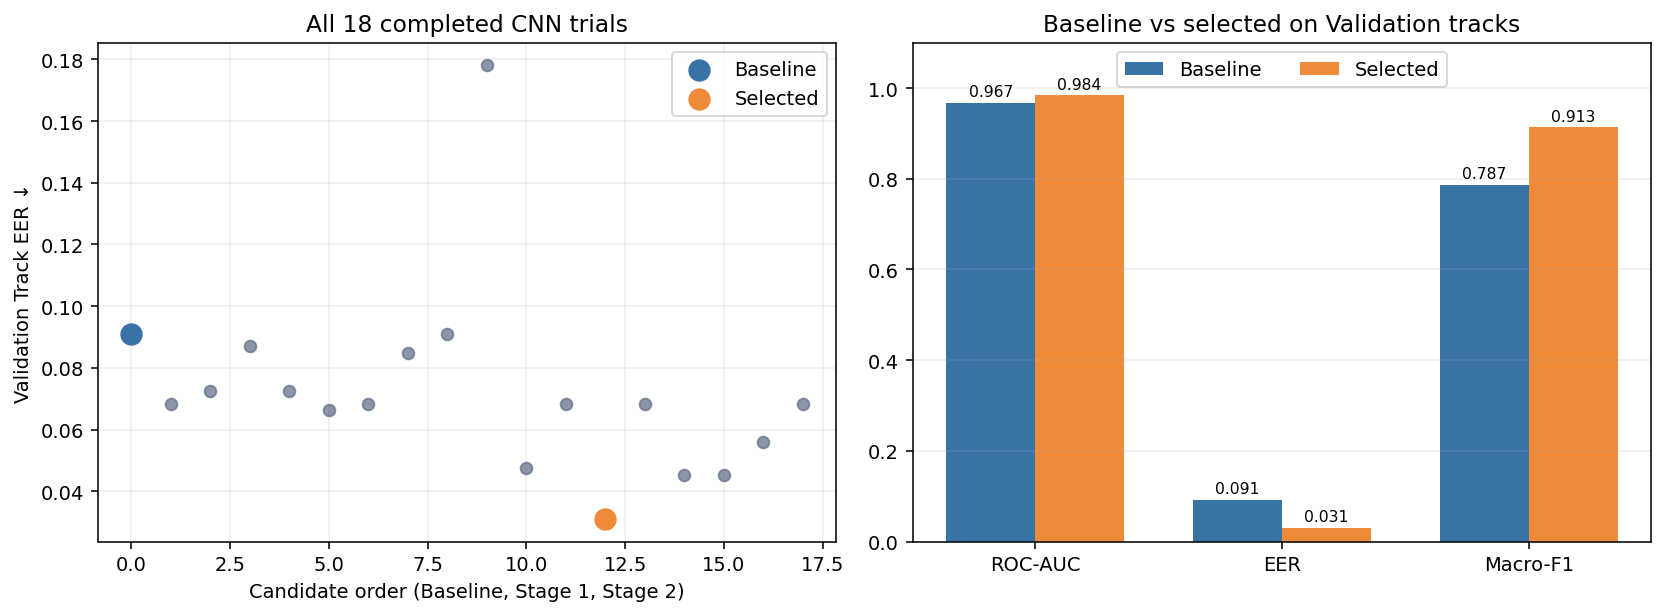

Saved: results/model_tuning/validation_comparisons/cnn_validation_comparison.png


In [9]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
candidates = pd.read_csv(result_dir / "cnn_tuning.csv").sort_values("candidate_order")
baseline_info = json.loads((result_dir / "cnn_baseline_selection.json").read_text())
selected_info = json.loads((result_dir / "cnn_optimized_selection.json").read_text())
assert len(candidates) == 18 and candidates["status"].eq("complete").all()
assert candidates["run_id"].nunique() == 1
assert candidates["run_id"].iloc[0] == baseline_info["run_id"] == selected_info["run_id"]
baseline = candidates.loc[candidates["trial_id"] == baseline_info["trial"]["trial_id"]].iloc[0]
selected = candidates.loc[candidates["trial_id"] == selected_info["trial"]["trial_id"]].iloc[0]
assert int(baseline["candidate_order"]) == baseline_info["trial"]["candidate_order"]
assert int(selected["candidate_order"]) == selected_info["trial"]["candidate_order"]

# 선택 설정과 세 가지 Validation Track 지표를 짧은 표로 만든다.
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "learning rate": [baseline["lr"], selected["lr"]],
    "dropout": [baseline["dropout"], selected["dropout"]],
    "batch size": [baseline["batch_size"], selected["batch_size"]],
    "weight decay": [baseline["weight_decay"], selected["weight_decay"]],
    "best epoch": [baseline["best_epoch"], selected["best_epoch"]],
    "Track ROC-AUC ↑": [baseline["track_roc_auc"], selected["track_roc_auc"]],
    "Track EER ↓": [baseline["track_eer"], selected["track_eer"]],
    "Track Macro-F1 ↑": [baseline["track_macro_f1"], selected["track_macro_f1"]],
})
display(summary.round(4))

# 18개 trial의 Validation EER와 선택된 두 trial을 함께 보여 준다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(candidates["candidate_order"], candidates["track_eer"], "o", color="#64748b", alpha=0.75)
axes[0].scatter([baseline["candidate_order"]], [baseline["track_eer"]], s=110, label="Baseline", color="#3973a6", zorder=3)
axes[0].scatter([selected["candidate_order"]], [selected["track_eer"]], s=110, label="Selected", color="#ef8b38", zorder=3)
axes[0].set_xlabel("Candidate order (Baseline, Stage 1, Stage 2)")
axes[0].set_ylabel("Validation Track EER ↓")
axes[0].set_title("All 18 completed CNN trials")
axes[0].legend()
axes[0].grid(alpha=0.2)
figure_path = figure_dir / "cnn_validation_comparison.png"
# 같은 Validation Track 지표를 두 설정에서 나란히 비교한다.
metric_names = ["ROC-AUC", "EER", "Macro-F1"]
baseline_values = [baseline["track_roc_auc"], baseline["track_eer"], baseline["track_macro_f1"]]
selected_values = [selected["track_roc_auc"], selected["track_eer"], selected["track_macro_f1"]]
positions = np.arange(len(metric_names))
baseline_bars = axes[1].bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
selected_bars = axes[1].bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
axes[1].bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].set_xticks(positions, metric_names)
axes[1].set_ylim(0, 1.10)
axes[1].set_title("Baseline vs selected on Validation tracks")
axes[1].legend(loc="upper center", ncol=2)
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))


## 10. CNN — 저장된 공동 Test 비교

저장된 공동 Test 결과의 같은 539곡을 비교한다. AUC·EER은 Test 점수에서 계산했고, Macro-F1·REAL FPR·FAKE miss에는 각 설정의 Validation 임계값을 적용했다. 여기서는 모델이나 임계값을 다시 선택하지 않는다.

설정,Validation threshold,ROC-AUC ↑,EER ↓,Macro-F1 ↑,REAL FPR ↓,FAKE miss ↓
Baseline,0.3603,0.9673,0.1111,0.7933,0.1111,0.0830
Selected,0.2411,0.9845,0.0749,0.8764,0.2000,0.0243


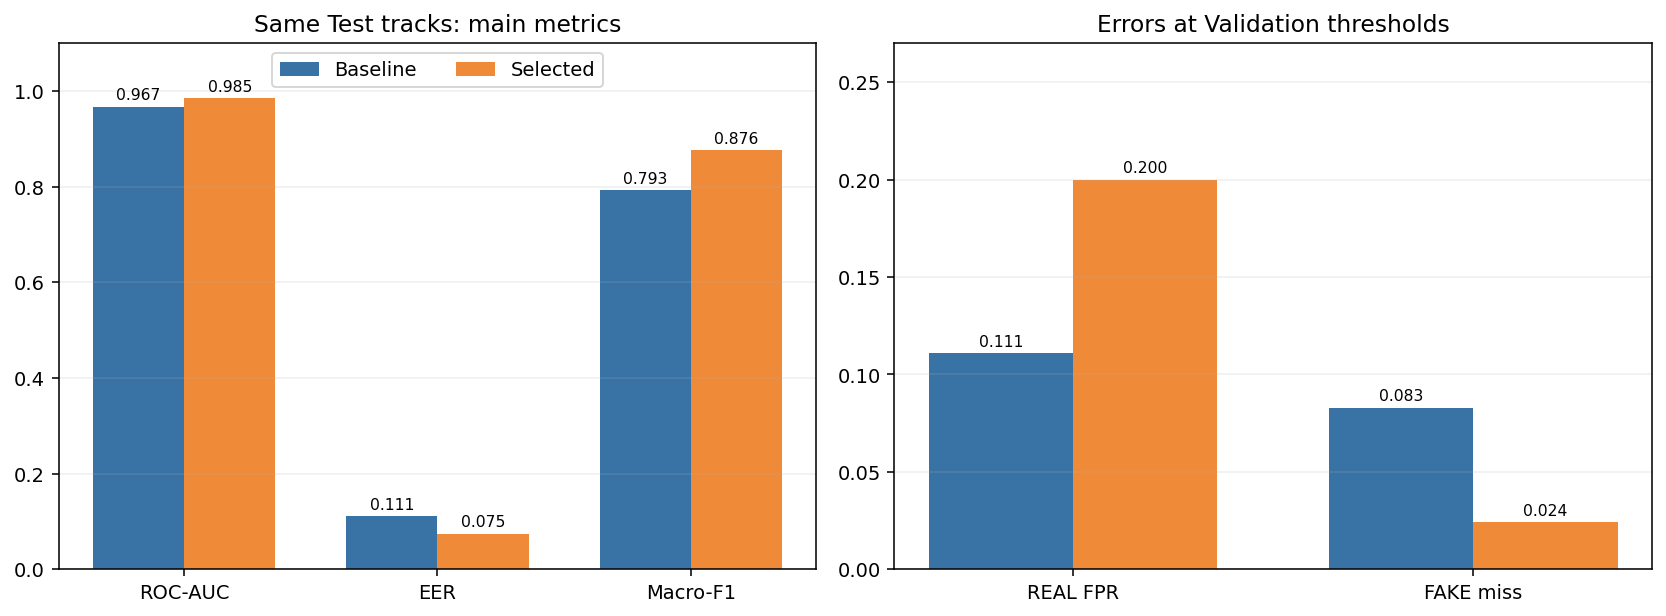

Saved: results/model_tuning/test_comparisons/cnn_test_comparison.png


In [10]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
# Validation 후보 그림과 공동 Test 그림은 폴더도 구분해 저장한다.
figure_dir = result_dir / "test_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)

# 최종 공동 Test CSV에서 이 모델의 곡 단위 두 행만 읽는다.
model_name = 'Log-Mel CNN'
final_results = pd.read_csv(result_dir / "optimized_test_results.csv")
rows = final_results.loc[
    (final_results["model"] == model_name)
    & (final_results["split"] == "test")
    & (final_results["level"] == "track")
].copy()
assert len(rows) == 2 and set(rows["variant"]) == {"baseline", "optimized"}
expected_run_id = json.loads((result_dir / "cnn_optimized_selection.json").read_text())["run_id"]
assert rows["run_id"].nunique() == 1 and rows["run_id"].iloc[0] == expected_run_id
assert rows["n"].eq(539).all() and rows["n_real"].eq(45).all() and rows["n_fake"].eq(494).all()
baseline = rows.set_index("variant").loc["baseline"]
selected = rows.set_index("variant").loc["optimized"]

# EER과 AUC는 Test 점수에서 계산됐다. 분류 오류율에는 각 설정의 Validation 임계값을 썼다.
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "Validation threshold": [baseline["threshold"], selected["threshold"]],
    "ROC-AUC ↑": [baseline["roc_auc"], selected["roc_auc"]],
    "EER ↓": [baseline["eer"], selected["eer"]],
    "Macro-F1 ↑": [baseline["macro_f1"], selected["macro_f1"]],
    "REAL FPR ↓": [baseline["real_fpr"], selected["real_fpr"]],
    "FAKE miss ↓": [baseline["fake_miss_rate"], selected["fake_miss_rate"]],
})
display(summary.round(4))

# 왼쪽은 앞의 Validation 비교와 같은 세 지표, 오른쪽은 오류 방향을 보여 준다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
main_metrics = [("ROC-AUC", "roc_auc"), ("EER", "eer"), ("Macro-F1", "macro_f1")]
error_metrics = [("REAL FPR", "real_fpr"), ("FAKE miss", "fake_miss_rate")]
for ax, metrics, title in [
    (axes[0], main_metrics, "Same Test tracks: main metrics"),
    (axes[1], error_metrics, "Errors at Validation thresholds"),
]:
    positions = np.arange(len(metrics))
    baseline_values = [baseline[column] for _, column in metrics]
    selected_values = [selected[column] for _, column in metrics]
    baseline_bars = ax.bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
    selected_bars = ax.bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
    ax.bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_xticks(positions, [label for label, _ in metrics])
    ax.set_ylim(0, 1.10 if ax is axes[0] else max(baseline_values + selected_values) * 1.3 + 0.01)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper center", ncol=2)
fig.tight_layout()
figure_path = figure_dir / 'cnn_test_comparison.png'
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))
